# DeepStomata: stomatal detection and aperture measurement

This notebook runs the author's pretrained models on all 11 supplied microscope images.
It detects stomata with HOG + SVM, classifies each detection into four states with a CNN,
and measures pore aperture where a pore can be segmented.
It does not train a model or repeat the paper's accuracy evaluation.

> **🇯🇵 日本語訳**  
> このノートブックは、著者の学習済みモデルを付属の顕微鏡画像11枚に適用します。  
> HOG + SVM で気孔を検出し、CNN で各検出領域を4つの状態に分類します。  
> 分割できた孔について開口量を測定します。モデルの学習や論文の精度評価は行いません。

## Why the implementation differs

The original 2018 program used Python 3.5, TensorFlow 0.12, and SciPy image functions
that are unavailable in current Colab runtimes.
This notebook uses Pillow for image loading and resizing, Keras with the author's
checkpoint tensors for the same CNN layers, and current SciPy/scikit-image for pore segmentation.
Its CSV keeps one complete row per detection, including false positives and failed pore measurements.
Library and resizing changes can affect numerical results.

> **🇯🇵 日本語訳**  
> 2018年の原著プログラムは Python 3.5、TensorFlow 0.12、および現在の Colab では使えない SciPy の画像関数を使用します。  
> このノートブックでは画像の読込と縮小に Pillow、同じ CNN 層と著者のチェックポイントには Keras、孔の分割には現行の SciPy／scikit-image を使用します。  
> CSV は誤検出や孔の測定失敗も含め、検出領域ごとに欠けのない1行を保存します。ライブラリや縮小処理の違いで数値が変わる可能性があります。

## Runtime and verification

Last complete run in a fresh Colab runtime: **2026-09-25 00:29 UTC**.
The standard CPU runtime had 2 logical cores, 8.67 GiB available RAM, no GPU,
Python 3.13.15, TensorFlow 2.20.0, and dlib 19.24.6.
All 11 images took **5.9 seconds for the analysis loop**; downloading assets and loading libraries took additional time.
CPU was sufficient, while Colab's free GPU availability varies.
TensorFlow layers may use a GPU if one is selected, but the dlib and image-processing stages remain on CPU;
a full GPU run has not been verified here.
AI-generated code and analysis cannot be guaranteed completely. Review the outputs before scientific use.

> **🇯🇵 日本語訳**  
> 新しい Colab runtime での最終通し実行は **2026年9月25日 00:29 UTC** です。  
> 標準 CPU runtime の実測値は論理コア2、空き RAM 8.67 GiB、GPU なし、Python 3.13.15、TensorFlow 2.20.0、dlib 19.24.6 でした。  
> 全11枚の**解析ループは5.9秒**で完了しました。資産の取得とライブラリ読込には別途時間がかかります。  
> CPU で十分に処理でき、Colab 無料枠の GPU 提供状況は変動します。GPU を選べば TensorFlow の層は GPU を利用し得ますが、dlib と画像処理は CPU 上で動きます。GPU での全工程は未検証です。  
> AI 生成コードと解析結果の完全な保証はできません。科学的利用の前に出力を確認してください。

## Sources and licenses

- **Paper:** [DeepStomata, bioRxiv DOI 10.1101/365098v1](https://www.biorxiv.org/content/10.1101/365098v1.full), listed in [PhenoPaper](https://phenopaper.smartbreed-plant-phenotyping-platform.com/papers/paper-manual-biorxiv-365098v1). The preprint page states **CC BY-NC 4.0** for the paper.
- **Code and bundled assets:** [totti0223/deepstomata](https://github.com/totti0223/deepstomata/tree/e4f5dd5d1a65232ed13f6bea6f4d1f02d1494558) at commit `e4f5dd5d1a65232ed13f6bea6f4d1f02d1494558`. Its [`LICENSE`](https://raw.githubusercontent.com/totti0223/deepstomata/e4f5dd5d1a65232ed13f6bea6f4d1f02d1494558/LICENSE) states **MIT** for the software. Check the current repository terms before redistributing assets.
- **Algorithm evidence:** `README.md` (three stages), `deepstomata/utils.py` (`stomata_detector`, `image_whitening`, `stomata_stat_batch_classify`, `pore_evaluator`, `analyze`), `deepstomata/stomata_model.py` (`tf_inference`), and `deepstomata/config.ini` (thresholds and pixel calibration), all at the commit above.

> **🇯🇵 日本語訳**  
> **論文：** [bioRxiv の DeepStomata](https://www.biorxiv.org/content/10.1101/365098v1.full)（DOI 10.1101/365098v1）。プレプリントのページには論文の利用条件として **CC BY-NC 4.0** と記載されています。[PhenoPaper の記録](https://phenopaper.smartbreed-plant-phenotyping-platform.com/papers/paper-manual-biorxiv-365098v1)にも掲載されています。  
> **コードと付属資産：** 上記の固定コミットの[著者リポジトリ](https://github.com/totti0223/deepstomata/tree/e4f5dd5d1a65232ed13f6bea6f4d1f02d1494558)にある `LICENSE` は、ソフトウェアを **MIT** としています。資産を再配布する際は、最新のリポジトリの条件も確認してください。  
> **手法の根拠：** 同じコミットの `README.md`、`deepstomata/utils.py`、`deepstomata/stomata_model.py`、`deepstomata/config.ini` の記載箇所を参照しています。


## 1. Check the runtime

**Why:** Library versions and available hardware can change between Colab sessions.
Recording them makes the saved result easier to interpret and helps diagnose future reruns.

**Input:** a fresh Colab runtime.  
**Action:** print the platform, CPU/GPU devices, available memory, and key library versions.  
**Output:** an environment record in the cell output. No Drive mount or secret is required.

The saved run used a standard CPU. A GPU is optional for a later rerun;
this cell reports what is actually available instead of requiring one device type.


In [1]:
# Capture the runtime actually used for this execution.
import os, platform, sys, time
from datetime import datetime, timezone
import numpy as np, scipy, skimage, PIL, cv2, dlib, tensorflow as tf
from IPython.display import display
print('Checked at UTC:', datetime.now(timezone.utc).isoformat())
print('Python:', sys.version.split()[0], 'Platform:', platform.platform())
print('CPU cores:', os.cpu_count(), 'GPU devices:', tf.config.list_physical_devices('GPU'))
print('Available RAM GiB:', round(os.sysconf('SC_AVPHYS_PAGES') * os.sysconf('SC_PAGE_SIZE') / 2**30, 2))
print('Versions:', {k: v for k,v in [('tensorflow',tf.__version__),('dlib',dlib.__version__),('numpy',np.__version__),('scipy',scipy.__version__),('scikit-image',skimage.__version__),('Pillow',PIL.__version__),('OpenCV',cv2.__version__)]})
# The same notebook can be rerun on CPU or GPU; the output above records the choice.


Checked at UTC: 2026-09-25T00:29:43.748669+00:00
Python: 3.13.15 Platform: Linux-6.6.122+-x86_64-with-glibc2.39
CPU cores: 2 GPU devices: []
Available RAM GiB: 8.67
Versions: {'tensorflow': '2.20.0', 'dlib': '19.24.6', 'numpy': '2.1.3', 'scipy': '1.16.3', 'scikit-image': '0.25.2', 'Pillow': '11.3.0', 'OpenCV': '5.0.0'}


## 2. Download and verify the author's files

**Why:** The detector, classifier, and example images must come from the same known
repository revision. SHA-256 checks catch incomplete downloads or changed files.

**Input:** the fixed GitHub commit, two pretrained model files, and 11 JPEGs.  
**Action:** download only those data files over HTTPS and verify size and SHA-256.  
**Output:** verified files in `/content/deepstomata_case/assets`.

The author's Python files are referenced for the method but are not imported or executed.


In [2]:
from pathlib import Path
import hashlib, urllib.request
# Pin downloads to one author commit, rather than a moving branch.
COMMIT = 'e4f5dd5d1a65232ed13f6bea6f4d1f02d1494558'
BASE = f'https://raw.githubusercontent.com/totti0223/deepstomata/{COMMIT}/'
ASSETS = {
 'deepstomata/models/leafdisk161002_c_7.0.svm': ('1c8aa41edf5dc9b30134dc992fc2d29d94f776d1bd0159c23ccaeb18370f09fe', 44688),
 'deepstomata/models/model.ckpt-5000': ('f5254868b74a3d96045d2580ca912a3c3f5aac3ad954b8ea1d48842a1f18c61e', 77562442),
 'examples/1.jpg': ('e1229c87c076cc373e29b2a2173d6ce385873f471021d1fb6d4a4386e9554995',699080),
 'examples/2.jpg': ('1097c85d3c68b1c7c7b8f8326e362700af7f35a99d1e814d5087749107c9f01c',548784),
 'examples/3.jpg': ('9ac53deb3bb4160b83655f5b096c80cb0caaff0eb9dd11b65c8f73f9f8c7f00b',530125),
 'examples/4.jpg': ('0a0cda66de37fe3e09de1ffdc0b127bc1f9203ebd048201e34825269b726a974',563802),
 'examples/5.jpg': ('bb5ca7f54c9ea229c44975b6e456a64960c952a30ad64ac871664bab1136ae73',690907),
 'examples/6.jpg': ('369d034d8cc2a8b2d2e6c6262ee13bd6892bea5f343ba3ec560fc36560ff25f5',788500),
 'examples/7.jpg': ('d8254f2f3eef7e9ffcdf7f74e7a7797070968bcf3bbda79ce3f146a62c38484f',723220),
 'examples/8.jpg': ('280c05b8097ca9ef5be70fea1f850b8a63f8ab91c45a68f9a9b5c6df4c11e7e1',714524),
 'examples/9.jpg': ('c0e66127fdf686c3c53d57fb02061e92cc90d3be89ed87918a206fceec56bf5d',679856),
 'examples/10.jpg': ('257bda164e9db726811eab1cb31806bdd1c449a6b3378738abc27a4ca01211fe',673297),
 'examples/11.jpg': ('32a679be711da4db9b9eac8e43c6515d260886e3b2f8c82422b65dca3ff79e06',700969),
}
ROOT = Path('/content/deepstomata_case')
# Verify every byte before the models or images are used.
for relative, (expected_hash, expected_size) in ASSETS.items():
    target = ROOT / 'assets' / relative
    target.parent.mkdir(parents=True, exist_ok=True)
    if not target.exists():
        with urllib.request.urlopen(BASE + relative, timeout=180) as response, target.open('wb') as out:
            while chunk := response.read(1024 * 1024): out.write(chunk)
    digest = hashlib.sha256(target.read_bytes()).hexdigest()
    assert target.stat().st_size == expected_size and digest == expected_hash, relative
print('Verified files:', len(ASSETS), 'total MiB:', round(sum(s for _,s in ASSETS.values()) / 2**20, 2))
print('Fixed commit:', COMMIT)

Verified files: 13 total MiB: 80.99
Fixed commit: e4f5dd5d1a65232ed13f6bea6f4d1f02d1494558


## 3. Load the original CNN weights

**Why:** The checkpoint contains tensors from an older TensorFlow graph that current
Keras cannot load as a ready-made model. Rebuilding the same layer shapes lets us use
the author's learned weights without retraining.

**Input:** the verified TensorFlow checkpoint.  
**Action:** build four convolution/pooling blocks and three dense layers, then copy
the 14 inference tensors by name. Adam and moving-average tensors are training state.  
**Output:** a Keras classifier; shape, finite-value, parameter-count, and probability checks.


In [3]:
from tensorflow import keras
# Read TensorFlow 1 checkpoint tensors without importing the legacy source code.
reader = tf.compat.v1.train.NewCheckpointReader(str(ROOT/'assets/deepstomata/models/model.ckpt-5000'))
model = keras.Sequential([keras.Input((56,56,3)),
    keras.layers.Conv2D(32,3,padding='same',activation='relu',name='conv1'), keras.layers.MaxPooling2D(3,strides=2,padding='same'),
    keras.layers.Conv2D(64,3,padding='same',activation='relu',name='conv2'), keras.layers.MaxPooling2D(3,strides=2,padding='same'),
    keras.layers.Conv2D(128,3,padding='same',activation='relu',name='conv3'), keras.layers.MaxPooling2D(3,strides=2,padding='same'),
    keras.layers.Conv2D(256,3,padding='same',activation='relu',name='conv4'), keras.layers.MaxPooling2D(3,strides=2,padding='same'),
    keras.layers.Flatten(), keras.layers.Dense(1024,activation='relu',name='fc5'),
    keras.layers.Dense(256,activation='relu',name='fc6'), keras.layers.Dense(4,name='fc7')])
# Match each Keras layer to the author's checkpoint variable names and shapes.
for layer in model.layers:
    if layer.name in ('conv1','conv2','conv3','conv4','fc5','fc6','fc7'):
        tensors = [reader.get_tensor(f'{layer.name}/{part}') for part in ('weights','biases')]
        assert all(np.isfinite(t).all() for t in tensors), layer.name
        assert [tuple(t.shape) for t in tensors] == [tuple(w.shape) for w in layer.weights], layer.name
        layer.set_weights(tensors)
        print(layer.name, [t.shape for t in tensors], 'weight L2', round(float(np.linalg.norm(tensors[0])),3))
assert model.count_params() == 4_847_172, model.count_params()
test_probs = tf.nn.softmax(model(np.zeros((1,56,56,3),np.float32),training=False)).numpy()
assert np.isfinite(test_probs).all() and np.allclose(test_probs.sum(axis=1),1,atol=1e-6)
print('Inference parameters:', model.count_params(), 'probe probabilities:', test_probs.round(4).tolist())

conv1 [(3, 3, 3, 32), (32,)] weight L2 5.242
conv2 [(3, 3, 32, 64), (64,)] weight L2 25.93
conv3 [(3, 3, 64, 128), (128,)] weight L2 50.013
conv4 [(3, 3, 128, 256), (256,)] weight L2 83.292
fc5 [(4096, 1024), (1024,)] weight L2 1.962
fc6 [(1024, 256), (256,)] weight L2 0.757
fc7 [(256, 4), (4,)] weight L2 6.641


Inference parameters: 4847172 probe probabilities: [[0.002400000113993883, 0.1160999983549118, 0.03280000016093254, 0.8485999703407288]]


## 4. Define detection, classification, and measurement

**Why:** The original workflow has three linked decisions. Detecting candidate regions
first avoids classifying every pixel; classification then determines which regions need
pore segmentation. Aperture is meaningful only when a qualifying pore is found.

**Input:** verified images, the dlib SVM, and the loaded CNN.  
**Action:** detect on a 512 px wide image, map boxes to source pixels, resize crops to
56×56, whiten each crop, classify into `open`, `closed`, `partially_open`, or
`false_positive`, and segment pores in the open classes.  
**Output:** reusable functions that return detections, class probabilities, and pore measurements.

Segmentation follows the source configuration: Gaussian σ=3, 31 px local threshold,
binary opening/closing, area 100–6000 px², solidity ≥0.8, major axis ≥40 px,
and 20% margins. The largest qualifying pore is used if several remain.


In [4]:
from PIL import Image, ImageDraw, ImageFont
from scipy import ndimage
from skimage.color import rgb2gray
from skimage.filters import threshold_local
from skimage.measure import label, regionprops
import csv
DETECTOR = dlib.simple_object_detector(str(ROOT/'assets/deepstomata/models/leafdisk161002_c_7.0.svm'))
CLASSES = ('open','closed','partially_open','false_positive')
PIXELS_PER_UM = 2.88

# Run the HOG detector on a 512 px image, then return source-pixel boxes.
def detect(image):
    width, height = image.size
    ratio = width / 512
    scaled = image.resize((512,round(height/ratio)), Image.Resampling.BILINEAR)
    rectangles = DETECTOR(np.asarray(scaled))
    boxes = []
    for d in rectangles:
        box = (max(1,round(d.left()*ratio)),max(1,round(d.top()*ratio)),
               min(width,round(d.right()*ratio)),min(height,round(d.bottom()*ratio)))
        if box[2] > box[0] and box[3] > box[1]: boxes.append(box)
    return sorted(boxes,key=lambda box:box[0])

# Standardize one 56×56 crop as the original image_whitening function does.
def whiten(crop):
    x = np.asarray(crop.resize((56,56),Image.Resampling.BILINEAR),dtype=np.float32)
    mean = x.mean()
    std = max(float(np.sqrt(np.mean(np.square(x))-mean*mean)),1/np.sqrt(x.size))
    return (x-mean)/std

# Segment a bright pore and convert its pixel measurements to micrometres.
def pore_metrics(crop):
    gray = ndimage.gaussian_filter(rgb2gray(np.asarray(crop)),3)
    binary = gray > threshold_local(gray,31,method='gaussian')
    binary = ndimage.binary_closing(ndimage.binary_opening(binary))
    h,w = binary.shape
    candidates = [p for p in regionprops(label(binary))
        if 100 <= p.area <= 6000 and p.solidity >= .8 and p.major_axis_length >= 40
        and .2*h <= p.centroid[0] <= .8*h and .2*w <= p.centroid[1] <= .8*w]
    if not candidates: return None
    p = max(candidates,key=lambda p:p.area)
    return {'aperture_um':float(p.minor_axis_length/PIXELS_PER_UM),
        'area_um2':float(p.area/PIXELS_PER_UM**2),
        'long_axis_um':float(p.major_axis_length/PIXELS_PER_UM),
        'aperture_to_long_axis':float(p.minor_axis_length/p.major_axis_length),
        'pore_centroid_x_px':float(p.centroid[1]),'pore_centroid_y_px':float(p.centroid[0]),
        'eccentricity':float(p.eccentricity),'solidity':float(p.solidity),
        '_coords':p.coords}

# Keep batches small enough for the standard CPU runtime.
def classify(crops):
    if not crops: return np.empty((0,4),np.float32)
    outputs=[]
    for offset in range(0,len(crops),32):
        batch=np.stack([whiten(c) for c in crops[offset:offset+32]])
        logits=model(batch,training=False)
        outputs.append(tf.nn.softmax(logits,axis=1).numpy())
    return np.concatenate(outputs)

FIELDS=['image','region_no','class','confidence','left_px','top_px','right_px','bottom_px',
        'aperture_um','area_um2','long_axis_um','aperture_to_long_axis',
        'pore_centroid_x_px','pore_centroid_y_px','eccentricity','solidity','pore_status']

## 5. Analyze all 11 images

**Why:** Running every bundled image checks that the full workflow works across the
author's examples, including closed stomata and false positives.

**Input:** all 11 verified JPEGs.  
**Action:** detect and classify each region, measure a pore for `open` and
`partially_open` predictions, and draw labels and measurement overlays.  
**Output:** `detections.csv`, `classification_counts.csv`, and 11 annotated JPEGs
under `/content/deepstomata_case/output`.

A blank aperture means no measurement. `closed` receives an aperture of zero;
`false_positive` is not measured. `no_pore_found` identifies an open prediction
without a qualifying segmented pore.


In [5]:
from collections import Counter
from IPython.display import display
OUTPUT=ROOT/'output'
OUTPUT.mkdir(exist_ok=True)
rows=[]; counts=[]; elapsed=[]
colors={'open':'#e02424','closed':'#1d70b8','partially_open':'#e68a00','false_positive':'#555555'}
font=ImageFont.load_default(size=20)
# Process every author-provided example; preserve one CSV row per detection.
for i in range(1,12):
    start=time.monotonic()
    name=f'{i}.jpg'
    image=Image.open(ROOT/'assets/examples'/name).convert('RGB')
    boxes=detect(image)
    crops=[image.crop(box) for box in boxes]
    probabilities=classify(crops)
    assert probabilities.shape==(len(boxes),4) and np.isfinite(probabilities).all()
    annotation=image.copy(); draw=ImageDraw.Draw(annotation)
    tally=Counter()
    for no,(box,crop,probs) in enumerate(zip(boxes,crops,probabilities),1):
        category=CLASSES[int(np.argmax(probs))]
        tally[category]+=1
        row=dict.fromkeys(FIELDS,'')
        row.update(image=name,region_no=no,**{'class':category},confidence=float(np.max(probs)),
                   left_px=box[0],top_px=box[1],right_px=box[2],bottom_px=box[3])
        # Only an open prediction can have a segmented pore measurement.
        metrics=pore_metrics(crop) if category in ('open','partially_open') else None
        if metrics:
            coords=metrics.pop('_coords')
            row.update(metrics)
            row['pore_status']='measured'
            for y,x in coords[::max(1,len(coords)//1200)]:
                draw.point((box[0]+int(x),box[1]+int(y)),fill='#22ee33')
        elif category=='closed':
            row['aperture_um']=0.0; row['pore_status']='not_applicable'
        elif category=='false_positive': row['pore_status']='not_applicable'
        else: row['pore_status']='no_pore_found'
        rows.append(row)
        draw.rectangle(box,outline=colors[category],width=5)
        label_text=f'{no} {category} ' + (f"{row['aperture_um']:.2f} um" if row['aperture_um']!='' else 'n.d.')
        draw.text((box[0],max(0,box[1]-27)),label_text,fill='white',font=font,stroke_width=3,stroke_fill=colors[category])
    annotated=OUTPUT/f'{i}_annotated.jpg'
    annotation.save(annotated,quality=85)
    counts.append({'image':name,**{c:tally[c] for c in CLASSES},'total':len(boxes)})
    seconds=time.monotonic()-start; elapsed.append(seconds)
    print(name, 'detections',len(boxes),'classes',dict(tally),'seconds',round(seconds,1))
# Write rectangular CSVs so missing measurements remain explicit.
with (OUTPUT/'detections.csv').open('w',newline='') as f:
    writer=csv.DictWriter(f,fieldnames=FIELDS);writer.writeheader();writer.writerows(rows)
with (OUTPUT/'classification_counts.csv').open('w',newline='') as f:
    fields=['image',*CLASSES,'total'];writer=csv.DictWriter(f,fieldnames=fields);writer.writeheader();writer.writerows(counts)
print('Total detections:',len(rows),'total seconds:',round(sum(elapsed),1),'annotated images:',len(list(OUTPUT.glob('*_annotated.jpg'))))

1.jpg detections 9 classes {'open': 8, 'closed': 1} seconds 0.7


2.jpg detections 13 classes {'open': 13} seconds 0.6


3.jpg detections 11 classes {'partially_open': 10, 'false_positive': 1} seconds 0.7


4.jpg detections 8 classes {'closed': 8} seconds 0.4


5.jpg detections 12 classes {'open': 11, 'partially_open': 1} seconds 0.8


...

7.jpg detections 11 classes {'open': 9, 'partially_open': 2} seconds 0.5


8.jpg detections 10 classes {'open': 10} seconds 0.5


9.jpg detections 9 classes {'partially_open': 8, 'closed': 1} seconds 0.4


10.jpg detections 10 classes {'closed': 7, 'partially_open': 2, 'false_positive': 1} seconds 0.3


11.jpg detections 9 classes {'open': 3, 'partially_open': 5, 'closed': 1} seconds 0.4
Total detections: 114 total seconds: 5.9 annotated images: 11


## 6. Check the generated results

**Why:** A completed cell alone does not show that the files contain sensible data.
These checks catch missing images, malformed CSVs, invalid probabilities,
and out-of-range measurements.

**Input:** the CSVs and annotated JPEGs from step 5.  
**Action:** check schemas, record totals, class names, box coordinates,
aperture values, and image dimensions; then display three examples.  
**Output:** explicit PASS text, summary counts, sample CSV records, and image previews.

Passing these checks confirms execution on the supplied examples.
It does not re-estimate the paper's accuracy on its evaluation dataset.


PASS: CSV schemas, 114 records, 11 image summaries, 11 annotated JPEGs
Class totals: {'open': 66, 'closed': 18, 'partially_open': 28, 'false_positive': 2}
Measured pores: 89
Aperture range (um): 0.0 to 14.795
Elapsed per image (s): [0.7, 0.6, 0.7, 0.4, 0.8, 0.6, 0.5, 0.5, 0.4, 0.3, 0.4]
CSV sample: [{'image': '1.jpg', 'region_no': '1', 'class': 'open', 'confidence': '0.9999999403953552', 'aperture_um': '13.185407733274156', 'pore_status': 'measured'}, {'image': '1.jpg', 'region_no': '2', 'class': 'closed', 'confidence': '0.9997720718383789', 'aperture_um': '0.0', 'pore_status': 'not_applicable'}, {'image': '1.jpg', 'region_no': '3', 'class': 'open', 'confidence': '0.9999999403953552', 'aperture_um': '13.777731731975022', 'pore_status': 'measured'}, {'image': '1.jpg', 'region_no': '4', 'class': 'open', 'confidence': '0.9999999403953552', 'aperture_um': '12.654989991142857', 'pore_status': 'measured'}, {'image': '1.jpg', 'region_no': '5', 'class': 'open', 'confidence': '0.999999940395355

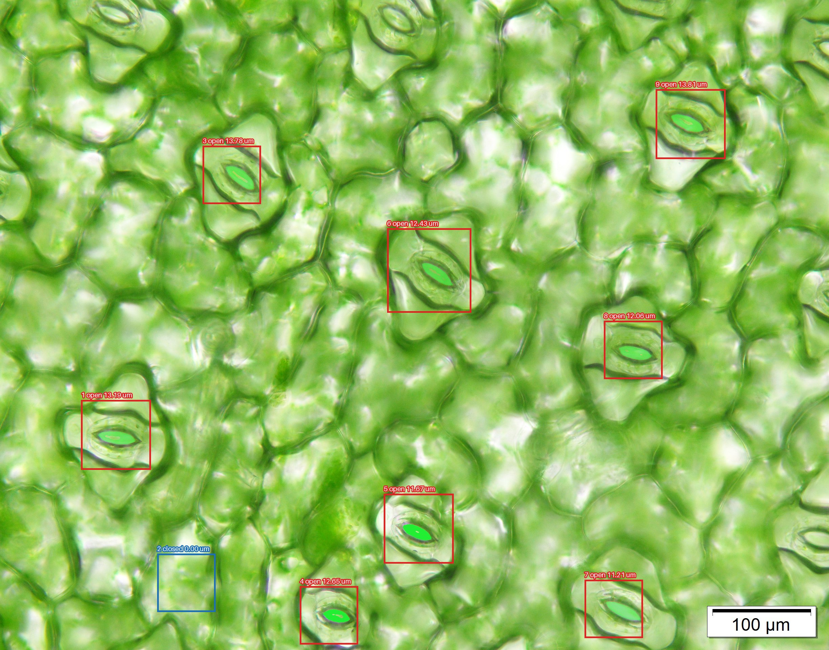

Annotated preview: 6


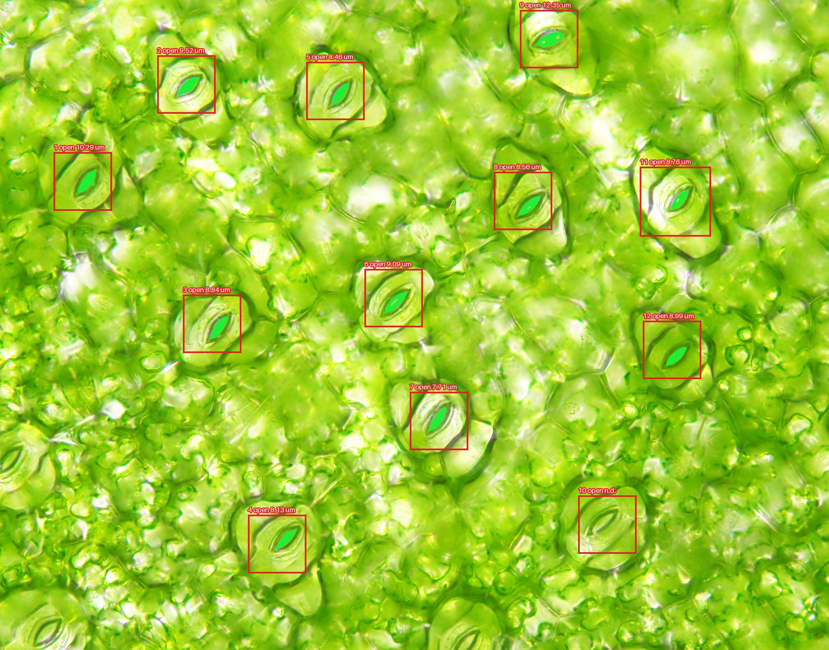

Annotated preview: 11


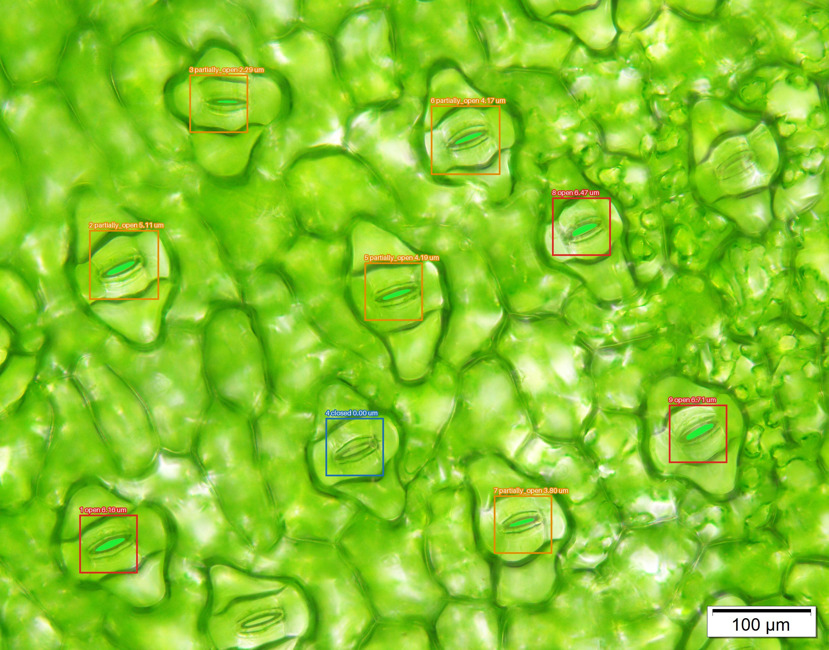

In [6]:
# Read the files back from disk; do not validate only in-memory results.
with (OUTPUT/'detections.csv').open(newline='') as f:
    reader=csv.DictReader(f); assert reader.fieldnames==FIELDS; saved=list(reader)
with (OUTPUT/'classification_counts.csv').open(newline='') as f:
    count_reader=csv.DictReader(f); assert count_reader.fieldnames==['image',*CLASSES,'total']; saved_counts=list(count_reader)
assert len(saved)==len(rows)>0 and len(saved_counts)==11
assert sum(int(c['total']) for c in saved_counts)==len(saved)
assert all(r['class'] in CLASSES and 0<=float(r['confidence'])<=1 for r in saved)
assert all(int(r['right_px'])>int(r['left_px']) and int(r['bottom_px'])>int(r['top_px']) for r in saved)
assert all(float(r['aperture_um'])>=0 for r in saved if r['aperture_um']!='')
assert any(r['pore_status']=='measured' and float(r['aperture_um'])>0 for r in saved)
# Confirm that every annotated JPEG opens and preserves source dimensions.
for i in range(1,12):
    with Image.open(ROOT/'assets/examples'/f'{i}.jpg') as source, Image.open(OUTPUT/f'{i}_annotated.jpg') as annotated:
        assert source.size==annotated.size and annotated.verify() is None
print('PASS: CSV schemas,',len(saved),'records, 11 image summaries, 11 annotated JPEGs')
print('Class totals:',dict(Counter(r['class'] for r in rows)))
print('Measured pores:',sum(r['pore_status']=='measured' for r in rows))
print('Aperture range (um):',round(min(float(r['aperture_um']) for r in saved if r['aperture_um']!=''),3),
      'to',round(max(float(r['aperture_um']) for r in saved if r['aperture_um']!=''),3))
print('Elapsed per image (s):',[round(s,1) for s in elapsed])
print('CSV sample:',[{k:r[k] for k in ('image','region_no','class','confidence','aperture_um','pore_status')} for r in saved[:5]])
for i in (1,6,11):
    picture=Image.open(OUTPUT/f'{i}_annotated.jpg'); picture.thumbnail((900,650))
    print('Annotated preview:',i);display(picture)

## Reading the result

The author's `stomata_detector` detects at 512 px width and maps boxes back to the
source image. `image_whitening` standardizes each 56×56 RGB crop.
`stomata_model.tf_inference` defines seven learned layers, and
`stomata_stat_batch_classify` maps their logits to four status labels.
`pore_evaluator` divides the pore's minor axis by the configured **2.88 px/µm**.

This notebook preserves those main steps. Its annotation style and rectangular CSV
layout are easier to inspect, and it selects the largest qualifying pore when several
are present. Check the pixel calibration before interpreting micrometre values from
another microscope or image scale.

The full-resolution CSVs and annotated JPEGs are in the temporary Colab runtime.
Download `/content/deepstomata_case/output` during a live run to keep them.
The saved notebook includes previews and validation output.
